# Business Scenario
A retail bank runs marketing campaigns to sell term deposit plans to customers.
Calling every customer is expensive and inefficient.

The bank wants a rule-based system that can decide:

 “Should we contact this customer or not?”

Management prefers a model whose decisions can be:
    - Clearly explained
    - Converted into if–else rules
    - Understood by non-technical staff

In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv("bank.csv")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [6]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [7]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [8]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [9]:
df.shape

(11162, 17)

In [10]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

# Task
1. Load the dataset and understand customer attributes such as:
    - Age
    - Job
    - Balance
    - Loan status
    - Contact history
2. Identify input features that may influence whether a customer subscribes to a term deposit
3. Build a model that can classify customers into:
    - Likely to Subscribe
    - Not Likely to subscribe.
4. Train the model using historical customer data.
5. Predict the outcome for unseen records.
6. Evaluate the model's performanace using suitable classification metrics.
7. Visualize the decision-making logic of the model.
8. Interpret the learned rules in simple business language.
9. Answer the following questions:
    - Which customer attribute appears at the top of the decision logic?
    - Why do you think this attribute is important?
10. Analyze model behavior:
    - 

In [11]:
# 1. Load the dataset and understand customer attributes such as: Age, Job, Balance, Loan status, Contact history

dd = df[['age', 'job', 'balance', 'loan', 'contact']]
dd.head()

,age,job,balance,loan,contact
0,59,admin.,2343,no,unknown
1,56,admin.,45,no,unknown
2,41,technician,1270,no,unknown
3,55,services,2476,no,unknown
4,54,admin.,184,no,unknown


In [12]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

dd['contact'] = encoder.fit_transform(dd['contact'])
dd['job'] = encoder.fit_transform(dd['job'])
dd['loan'] = encoder.fit_transform(dd['loan'])

dd.head()

C:\Users\rakes\AppData\Local\Temp\ipykernel_27216\747992566.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dd['contact'] = encoder.fit_transform(dd['contact'])
C:\Users\rakes\AppData\Local\Temp\ipykernel_27216\747992566.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dd['job'] = encoder.fit_transform(dd['job'])
C:\Users\rakes\AppData\Local\Temp\ipykernel_27216\747992566.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_i

,age,job,balance,loan,contact
0,59,0,2343,0,2
1,56,0,45,0,2
2,41,9,1270,0,2
3,55,7,2476,0,2
4,54,0,184,0,2


In [13]:
X = dd.drop('loan', axis = 1)
y = dd['loan']

X.head()

,age,job,balance,contact
0,59,0,2343,2
1,56,0,45,2
2,41,9,1270,2
3,55,7,2476,2
4,54,0,184,2


In [14]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: loan, dtype: int64

# Training the Data

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [16]:
y_pred = model.predict(X_test)

In [17]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.87


In [18]:
# Evaluate the model
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.93      2932
           1       0.38      0.02      0.04       417

    accuracy                           0.87      3349
   macro avg       0.63      0.51      0.48      3349
weighted avg       0.82      0.87      0.82      3349



In [19]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[2919   13]
 [ 409    8]]


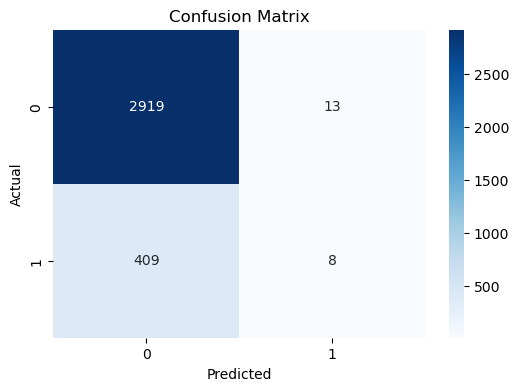

In [20]:
# Confusion Matrix Plotting
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

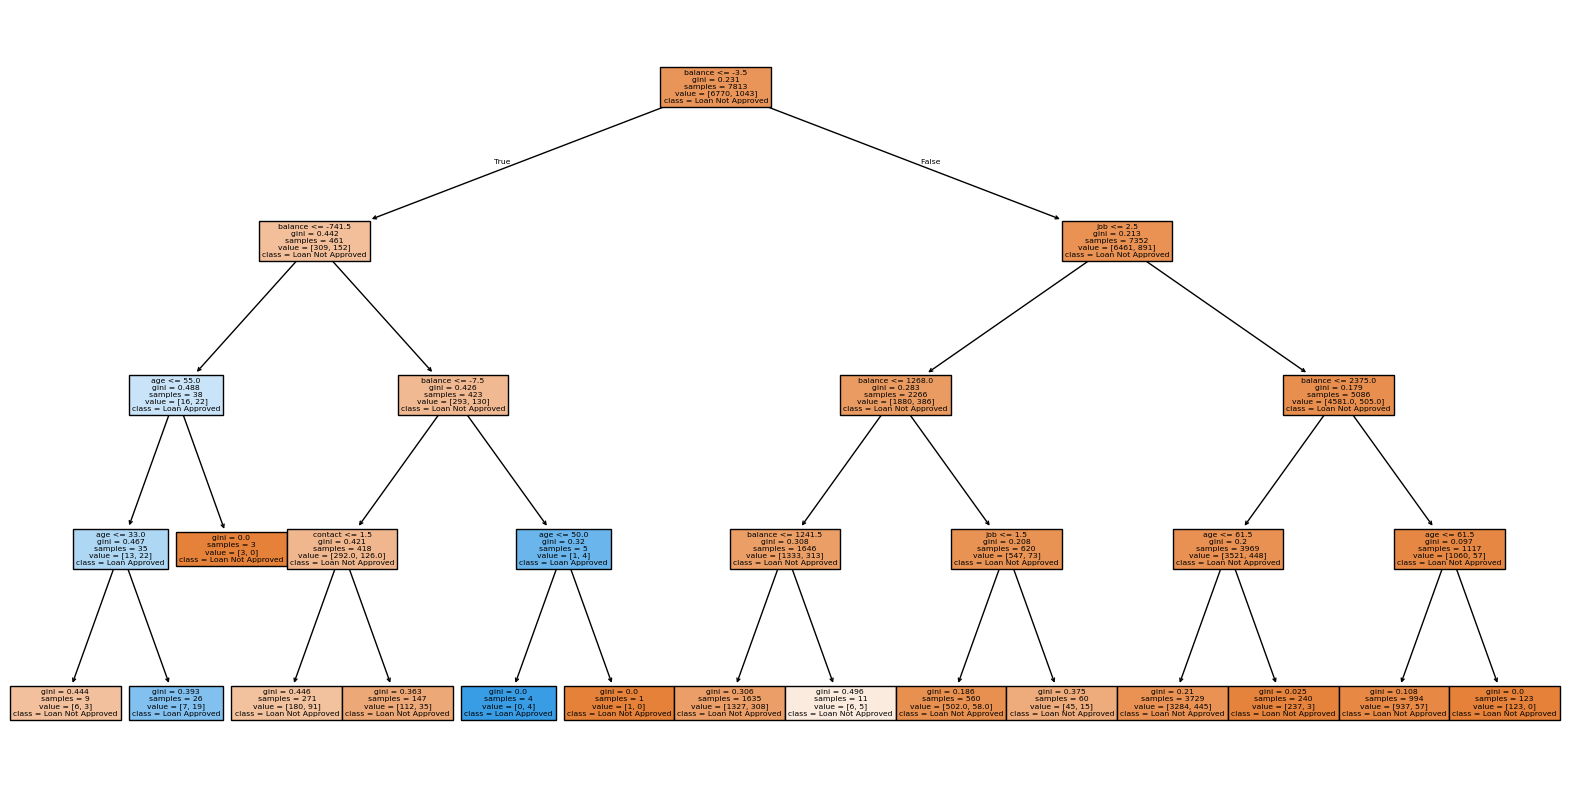

In [21]:
from sklearn.tree import plot_tree

plt.figure(figsize = (20, 10))
plot_tree(model, feature_names = X.columns, class_names = ["Loan Not Approved", "Loan Approved"], filled = True)
plt.show()

In [22]:
new_person = pd.DataFrame([[43, 2, 9000, 1]], columns=['age', 'job', 'balance', 'contact'])
prediction = model.predict(new_person)
print("Loan Approval Prediction (0 = Not Approved, 1 = Approved):", prediction[0])
if prediction[0] == 1:
    print("The loan is approved for the new customer.")
else:
    print("The loan is not approved for the new customer.")

Loan Approval Prediction (0 = Not Approved, 1 = Approved): 0
The loan is not approved for the new customer.
